# Tutorial

This notebook demonstrates pixels-to-actions training using the **3D Gaussian Splatting (3DGS)** rendering backend.

### Usage

Please note that this Colab **does not support a hosted runtime**. To use it, please install Playground on your local device and select `Connect to a local runtime`, or download the notebook to run locally! We recommend a device with at least 24 GB VRAM, such as the RTX4090.

In [1]:
%env MUJOCO_GL=egl
%env CUDA_VISIBLE_DEVICES=2
%env XLA_PYTHON_CLIENT_MEM_FRACTION=0.3
%env XLA_PYTHON_CLIENT_PREALLOCATE=false # Ensure that Madrona gets the chance to pre-allocate memory before Jax

# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools

from brax.training.agents.ppo import networks_vision as ppo_networks_vision
from brax.training.agents.ppo import train as ppo
from flax import linen
from IPython.display import clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
import numpy as np

from mujoco_playground import manipulation
from mujoco_playground import wrapper
from mujoco_playground._src import mjx_env
from mujoco_playground._src.manipulation.airbot_play import randomize_3dgs as randomize
from mujoco_playground.config import manipulation_params

np.set_printoptions(precision=3, suppress=True, linewidth=100)

env: MUJOCO_GL=egl
env: CUDA_VISIBLE_DEVICES=2
env: XLA_PYTHON_CLIENT_MEM_FRACTION=0.3
env: XLA_PYTHON_CLIENT_PREALLOCATE=false # Ensure that Madrona gets the chance to pre-allocate memory before Jax
Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Module` will soon be removed from the public API. Use `warp.Module` instead.
Warp DeprecationWarning: The symbol `warp.context.get_module` will soon be removed from the public API. Use `warp.get_module` instead.
Warp DeprecationWarning: The namespace `warp.math` will soon be removed from the public API. It can still be accessed from `warp._src.math` but might be changed or removed without notice.


## Picking up a Cube from Pixels

This tutorial uses the **BatchSplatWrapper** which leverages 3D Gaussian Splatting for high-performance batched rendering.

*Domain Randomization*

Just like in physics simulation, the mismatch between the simulated environment that the policy is trained on and the real-world setting in which it is deployed can be minimised either by meticulously calibrating the simulation or by randomizing simulation parameters such that the policy learns to be robust to a wide variety of ranges. We support domain randomisation, rendering different camera poses and geometry appearances across parallel environments.

*Coming up*

To keep the runtime for this task short and to simplify real-world transfer, we've adapted the [bring_to_target](https://github.com/kevinzakka/mujoco_playground/blob/main/mujoco_playground/_src/manipulation/franka_emika_panda/bring_to_target.py) task to the 2D case and introduce a task-space controller. These changes allow the policy to converge in well under ten million samples using a low-resolution single-camera RGB input.

In [2]:
from ml_collections import ConfigDict

env_name = "AirbotPlayPickCube"
env_cfg = manipulation.get_default_config(env_name)

# Pre-register body_gaussians to allow override
with env_cfg.unlocked():
    env_cfg.vision_config.body_gaussians = ConfigDict()
    env_cfg.vision_config.background = None

num_envs = 1024
episode_length = int(4 / env_cfg.ctrl_dt)

Reso = "224"
ASSETS_PATH = mjx_env.ROOT_PATH / "manipulation" / "airbot_play" / "3dgs"
# Configure for 3DGS rendering
config_overrides = {
    "episode_length": episode_length,
    "vision": True,
    "vision_config.render_batch_size": num_envs,
    "vision_config.render_width": 64,
    "vision_config.render_height": 64,
    "vision_config.background" : (ASSETS_PATH / "ribbon_blue.ply").as_posix(),
    "vision_config.body_gaussians": {
        "arm_base"  : (ASSETS_PATH / Reso / "arm_base.ply").as_posix(),
        "link1"     : (ASSETS_PATH / Reso / "link1.ply").as_posix(),
        "link2"     : (ASSETS_PATH / Reso / "link2.ply").as_posix(),
        "link3"     : (ASSETS_PATH / Reso / "link3.ply").as_posix(),
        "link4"     : (ASSETS_PATH / Reso / "link4.ply").as_posix(),
        "link5"     : (ASSETS_PATH / Reso / "link5.ply").as_posix(),
        "link6"     : (ASSETS_PATH / Reso / "link6.ply").as_posix(),
        "left"      : (ASSETS_PATH / Reso / "left.ply").as_posix(),
        "right"     : (ASSETS_PATH / Reso / "right.ply").as_posix(),
        "box"       : (ASSETS_PATH / "green_cube.ply").as_posix(),
    },
    "success_threshold": 0.03
}

env = manipulation.load(env_name, config=env_cfg, 
                        config_overrides=config_overrides
)
randomization_fn = functools.partial(randomize.domain_randomize,
                                        num_worlds=num_envs
)
env = wrapper.wrap_for_brax_training(
    env,
    vision=True,
    num_vision_envs=num_envs,
    episode_length=episode_length,
    action_repeat=1,
    randomization_fn=randomization_fn
)
num_cam = env.mj_model.ncam

#### Visualize the Environment

To make our policy robust to differences between the simulation environment and reality, we randomize the colors of the background and the target as well as the camera pose.

In [3]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

def tile(img, d):
    assert img.shape[0] == d*d
    img = img.reshape((d,d)+img.shape[1:])
    return np.concat(np.concat(img, axis=1), axis=1)

def unvmap(x):
    return jax.tree.map(lambda y: y[0], x)

/root/miniconda3/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


Warp DeprecationWarning: The symbol `warp.types.torch` will soon be removed from the public API. It can still be accessed from `warp._src.types.torch` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.utils.torch` will soon be removed from the public API. It can still be accessed from `warp._src.utils.torch` but might be changed or removed without notice.
Warp DeprecationWarning: The namespace `warp.torch` will soon be removed from the public API. It can still be accessed from `warp._src.torch` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.torch.contiguous_format` will soon be removed from the public API. It can still be accessed from `warp._src.torch.contiguous_format` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.torch` will soon be removed from the public API. Use `warp.torch` instead.
Warp DeprecationWarning: The symbol `warp.math.torch` will soon 

/root/miniconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py:2356: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


""

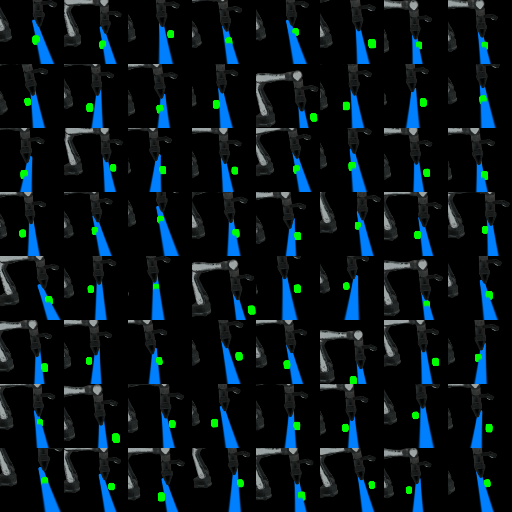

""

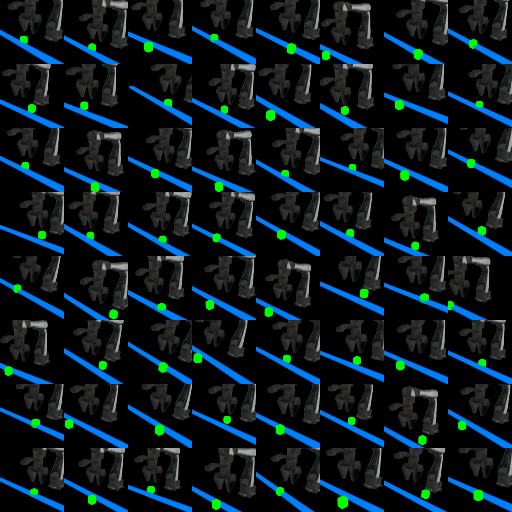

In [4]:
state = jit_reset(jax.random.split(jax.random.PRNGKey(0), num_envs))
for i in range(num_cam):
    media.show_image(tile(state.obs[f'pixels/view_{i}'][:64], 8), width=512)

To improve sample efficiency and facilitate real-world transfer, we use a cartesian action space in the y and z dimensions. This conditions out the underlying physics and removes the need for a stereo camera setup or depth sensor. We additionally discretize the gripper's action space so that it's fully opened or closed.

In [5]:
state = jit_reset(jax.random.split(jax.random.PRNGKey(0), num_envs))

f = 0.2
frames = {i : [] for i in range(num_cam)}
for i in range(env_cfg.episode_length):
  action = []
  for j in range(env.action_size):
    action.append(
        jp.sin(
            unvmap(state.data.time) * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
        )
    )
  action = jp.tile(jp.array(action), (num_envs, 1))
  state = jit_step(state, action)
  for i in range(num_cam):
    frames[i].append(unvmap(state).obs[f'pixels/view_{i}'])

for i in range(num_cam):
  media.show_video(frames[i], fps=1.0 / env.dt)

/root/miniconda3/lib/python3.10/site-packages/jax/_src/interpreters/xla.py:119: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


This browser does not support the video tag.


This browser does not support the video tag.


## Train

The policy trains in 40 min 11 sec on a h20 GPU.

In [6]:
network_factory = functools.partial(
    ppo_networks_vision.make_ppo_networks_vision,
    policy_hidden_layer_sizes=[256, 256],
    value_hidden_layer_sizes= [256, 256],
    activation=linen.relu,
    normalise_channels=True
)

ppo_params = manipulation_params.brax_vision_ppo_config(env_name)
ppo_params.num_timesteps = 7_000_000
ppo_params.num_envs = num_envs
ppo_params.num_eval_envs = num_envs
del ppo_params.network_factory
ppo_params.network_factory = network_factory

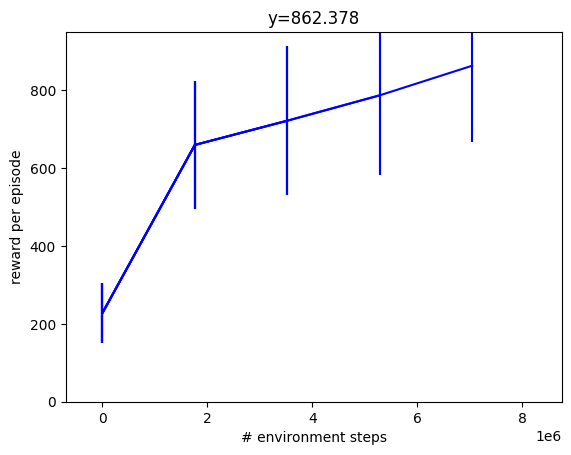

time to jit: 0:04:22.158332
time to train: 0:40:07.314158


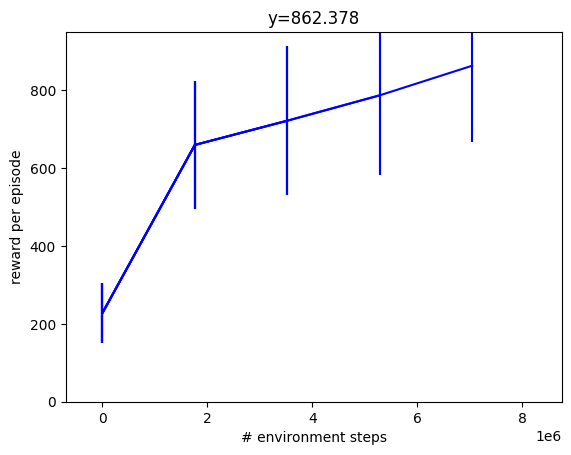

In [7]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  steps = ppo_params["num_timesteps"]
  plt.xlim([steps * -0.1, steps * 1.25])
  # plt.ylim([0, 14])
  plt.ylim([0, y_data[-1] * 1.1])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())


train_fn = functools.partial(
    ppo.train,
    augment_pixels=True,
    **dict(ppo_params),
    progress_fn=progress
)

make_inference_fn, params, metrics = train_fn(environment=env)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

#### Visualize Policy

In [8]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

2026-01-04 08:14:13.921040: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


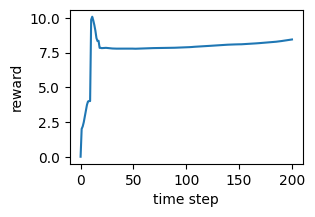

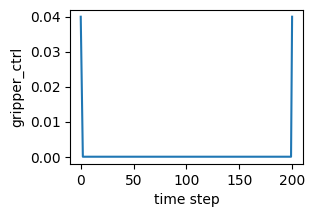

In [9]:
rng = jax.random.PRNGKey(0)
rollout = []
n_episodes = 1
to_keep = 256

def keep_until(state, i):
    return jax.tree.map(lambda x: x[:i], state)

for _ in range(n_episodes):
    key_rng = jax.random.split(rng, num_envs)
    state = jit_reset(key_rng)
    rollout.append(keep_until(state, to_keep))
    for i in range(env_cfg.episode_length):
        act_rng, rng = jax.random.split(rng)
        act_rng = jax.random.split(act_rng, num_envs)
        ctrl, _ = jit_inference_fn(state.obs, act_rng)
        state = jit_step(state, ctrl)
        rollout.append(keep_until(state, to_keep))

rewards = [unvmap(s).reward for s in rollout]
plt.figure(figsize=(3, 2))
plt.plot(rewards)
plt.xlabel("time step")
plt.ylabel("reward")
plt.show()

gripper_ctrl = [unvmap(s).data.ctrl[-1] for s in rollout]
plt.figure(figsize=(3, 2))
plt.plot(gripper_ctrl)
plt.xlabel("time step")
plt.ylabel("gripper_ctrl")
plt.show()

As a finale, let's peek at some of the worlds our policy has been training in:

In [10]:
obs_raw = [
    np.concatenate([
        np.array(
            s.obs[f'pixels/view_{i}']
        ) for i in range(num_cam)
    ], axis=-2)  for s in rollout
]
obs = [tile(img, int(np.sqrt(to_keep))) for img in obs_raw]
media.show_video(obs, fps=1.0/env_cfg.ctrl_dt, width=2048)

This browser does not support the video tag.
